In [1]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import pandas as pd

## Часть 1. Эффективность использования мощности ветрового потока или коэффициент мощности (Модель Берца-Жуковского)

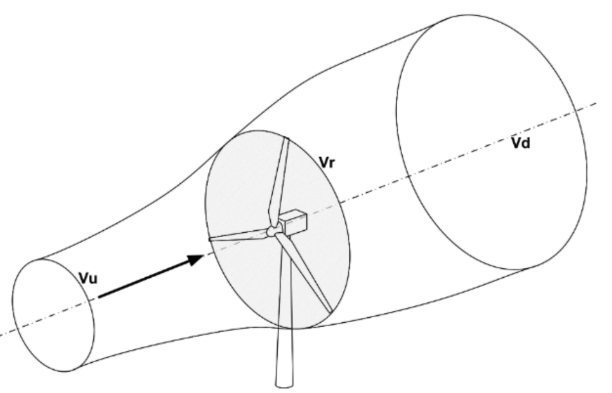

Обозначения (на pисунке):
- `Vu` — скорость потока **перед** ротором
- `Vd` — скорость потока **далеко за** ротором (slipstream)
- `Vr` — скорость в плоскости ротора (среднее между `Vu` и `Vd`)

**По параметрам до колеса имеем:**

Скоростной напор потока перед колесом:
$$ q = \tfrac12 \rho V_u^2 $$
Характерная аэродинамическая сила, связанная с потоком воздуха, проходящим через площадь ометаемую лопастью ветряка:

$$ qA = \tfrac12 \rho A V_u^2 $$
Ометаемая площадь ротора определяется выражением

$$A = \pi R^2 = \pi \left(\frac{D}{2}\right)^2, $$

где $(R)$ — радиус ротора, $(D)$ — диаметр ветроколеса.

Полная мощность ветрового потока:
$$ P_{wind} = qA V_u
$$

**Силы и мощность на колесе турбины**

Сила равна изменению количества движения воздуха в единицу времени:
$$ F = \dot m \left( V_u - V_d \right) $$
Мощность, развиваемая этой силой:
$$ P_{turb} = F  V_r = \dot m V_r \left( V_u - V_d \right) $$
Та же мощность как потеря кинетической энергии потока:
$$ P_{turb} = \frac{1}{2} \dot m V_u^2 - \frac{1}{2} \dot m V_d^2 = \frac{1}{2} \dot m \left( V_u^2 - V_d^2 \right) $$
Приравнивание выражений для мощности  и сокращая на $ \dot m $, получаем:
$$ V_r \left( V_u - V_d \right)
= \frac{1}{2} \left( V_u^2 - V_d^2 \right)
= \frac{1}{2} \left( V_u - V_d \right)\left( V_u + V_d \right) $$
в итоге:
$$ V_r =  \frac{1}{2} \left( V_u + V_d \right) $$

Массовый расход воздуха через плоскость ротора:
$$ \dot m = \rho A V_r $$
И итоговое выражение для мощности турбины:
$$ P_{turb} = \rho A V_r^2 \left( V_u - V_d \right) $$
Если подставить в формулу для мощности уравнение связи скоростей, то:
$$P
= \rho A V_r^2 \bigl[ V_u - (2V_r - V_u) \bigr]
= 2 \rho A (V_u - V_r) V_r^2$$

**Коэффициент торможения потока**

Вводится коэффициент торможения (индукции) потока `𝑎`, определяемый как относительное уменьшение скорости набегающего потока в плоскости ротора:
$$ a = \frac{V_u - V_r}{V_u} $$
с учетом соотношения для скоростей:
$$ a = \frac{V_u - V_d}{2 V_u} $$

Подставляя это выражение в формулу для мощности можно получить:
$$ P_{turb} = 2 \rho A (1 - a)^2 V_u^2
   \bigl[ V_u - (1 - a) V_u \bigr] \\
     = 2 \rho A V_u^3 (1 - a)^2 a \\
     = \frac{1}{2} \rho A V_u^3 \, 4a(1 - a)^2 $$
С учетом связи с выражением для полной мощности можно получить:
$$ P_{turb} = C_p P_{wind}, $$ 
где коэффициент использования мощности ветрового потока равен
$$ C_p = 4a(1 - a)^2 $$

Создадим функцию для турбины Берца-Жуковского, которая по величине `a`, диаметру ротора, плотности воздуха и скорости ветра возвращает параметры установки:

In [2]:
def betz_turbine(a, Dr=10.0, rho=1.225, Vu=10.0):
    Area = np.pi/4*Dr**2               # площадь турбины
    qA = 0.5 * rho * Area * Vu**2      # характерная аэродинамическая сила на роторе
    Vd = Vu * (1 - 2*a)                # скорость потока за ротором
    Vr = 0.5 * (Vu + Vd)               # скорость в плоскости ротора      
    Pwind =  qA*Vu                     # полная мощность ветрового потока 
    Cp = 4*a*(1-a)**2                  # коэффициент использования мощности ветрового потока     
    Pturb = Cp*Pwind                   # полезная мощность
    return dict(a=a, Area=Area, rho=rho, Vu=Vu, Vr=Vr, Vd=Vd, Pwind=Pwind, Cp=Cp, Pturb=Pturb)

In [3]:
# тестируем
test = betz_turbine(0.5)
test["Cp"]

0.5

Построим график Cp от `a`

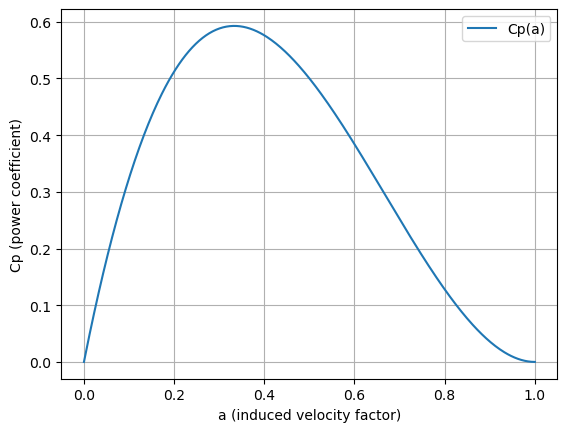

In [4]:
a_grid = np.linspace(0.0, 1.0, 400)
Cp_grid = [betz_turbine(a)["Cp"] for a in a_grid]

plt.figure()
plt.plot(a_grid, Cp_grid, label="Cp(a)")
plt.xlabel("a (induced velocity factor)")
plt.ylabel("Cp (power coefficient)")
plt.legend()
plt.grid(True)
plt.show()

Существует простой способ найти минимум(в нашем случае максимум) функции - решить оптимизационную задачу. Можно было бы просто производную аналитически и корни уравнения или просто найти максимальное значение на мелкой сетке, но мы не такие!

In [5]:
# функция цели
def objective(x):
    return -betz_turbine(x[0])["Cp"]

In [6]:
# начальное значение для итераций
x0 = np.array([0.5])               # начальное приближение как в примере
# ограничение параметра
bounds = [(0.0, 1.0)]
# поиск минимума
res = minimize(objective, x0=x0, method="SLSQP", bounds=bounds)
print(f'Оптимальное значение параметра a = {res.x[0]:0.3f}')

Оптимальное значение параметра a = 0.333


In [7]:
# получим максимально возможное число Сp
test = betz_turbine(res.x[0])
test["Cp"]

np.float64(0.5925925906671251)

Аналитически максимум достигается при:

$$ a = \tfrac13,\qquad C_{p,\max} = \tfrac{16}{27}\approx 0.59259 $$

## Часть 2. Существующая ветроустановки

**Создадим класс для ветровой турбины**

In [8]:
class WindTurbine:
    def __init__(self,
                 name: str,                        # turbine name
                 Dr,                               # rotor diameter
                 cut_in: float = 3.0,              # minimal velocity
                 rw_speed: float = 10.0,           # rated wind speed
                 cut_out: float = 25.0,            # maximum velocity
                 rho: float = 1.225,               # air density
                 eta_m: float = 0.95,              # mech. efficiency coefficient
                 cp_model: str = "betz",           # betz model using
                 grid_n: int = 100,                # points to caclulate
                 cp_points: tuple[np.ndarray, np.ndarray] | None = None,  # (V, Cp)
                ):
        self.name = name
        self.D = Dr
        self.R = self.D / 2.0
        self.A = np.pi * self.R**2
        self.rw_speed = rw_speed
        self.cut_in = cut_in
        self.cut_out = cut_out
        self.rho = rho
        self.eta = eta_m
        self.cp_model = cp_model
        self.cp_value = 0.59259                          # betz Cp value
        self.cp_points = cp_points
        self.np = grid_n
        self._get2Cp()                                   # получим Cp и Vp таблицы 
        self._get2curve()
    def _get2Cp(self):                              # хотим получить значения Cp для всего интервала ветровой нагрузки(по скорости)
       self.Vp = np.linspace(self.cut_in, self.cut_out, self.np)
       if self.cp_model == "betz":
           self.Cp = self.cp_value*np.ones(self.np)
       else:
           V_p, Cp_p = self.cp_points
           self.Cp = np.interp(self.Vp, V_p, Cp_p, left=Cp_p[0], right=Cp_p[-1])

    def _get2curve(self):                           # определение основных параметров кривой по скорости                        
        self.qA = 0.5 * self.rho * self.A * self.Vp**2   # характерная аэродинамическая сила на роторе
        self.Pwind =  self.qA*self.Vp                    # полная мощность ветрового потока
        self.Pturb = self.Cp*self.Pwind*self.eta         # полезная мощность
        # "заморозить" Cp после rw_speed на уровне Cp(rw_speed)
        Pturb_rw = float(np.interp(self.rw_speed, self.Vp, self.Pturb))
        self.Pturb[self.Vp >= self.rw_speed] = Pturb_rw

    def parameters4vel(self, Vel):                  # определение основных параметров для конкретной скорости набегающего потока
        Cp = np.interp(Vel, self.Vp, self.Cp)
        qA = 0.5 * self.rho * self.A * Vel**2       # характерная аэродинамическая сила на роторе
        Pwind =  qA*Vel                             # полная мощность ветрового потока 
        Pturb = Cp*Pwind*self.eta                   # полезная мощность
        return dict(Cp=Cp.item(), qA=qA, Pwind=Pwind, Pturb=Pturb.item())
    def clone(self, **kwargs):                      # копирование экземпляра класс 
        import copy
        new = copy.deepcopy(self)
        for k, v in kwargs.items():
            setattr(new, k, v)
        return new
    def recalc(self):
        self._get2Cp()
        self._get2curve()

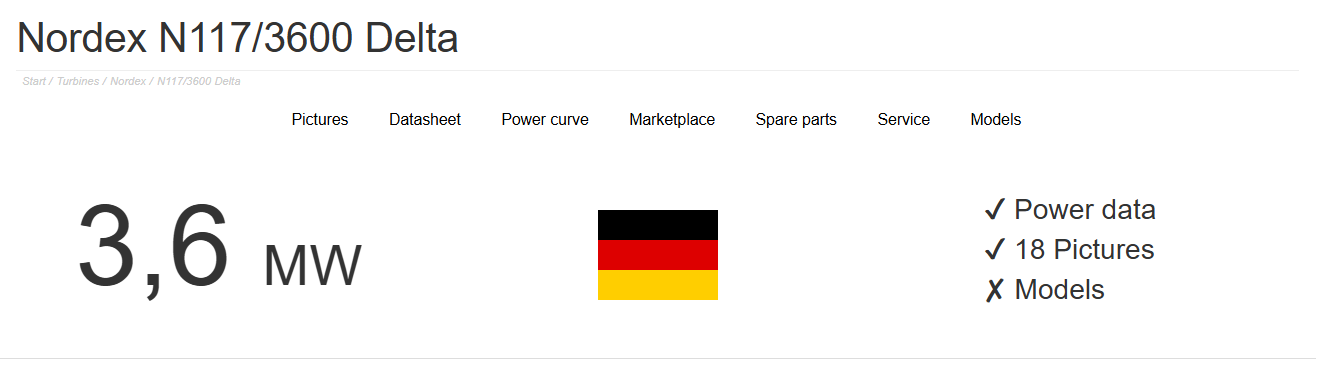

https://en.wind-turbine-models.com/turbines/1472-nordex-n117-3600-delta

In [9]:
# Nordex N117 Gamma
# данные для кривой мощности действительные
# https://en.wind-turbine-models.com/turbines/96-nordex-n117-gamma
V_data = [3, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10, 10.5, 11, 11.5, 12, 12.5, 13, 13.5, 14, 14.5, 
          15, 15.5, 16, 16.5, 17, 17.5, 18, 18.5, 19, 19.5, 20, 20.5, 21, 21.5, 22, 22.5, 23, 23.5, 24, 24.5, 25]
P_data = np.array([17.00, 54.00, 131.00, 228.00, 344.00, 479.00, 638.00, 823.00, 1038.00, 1284.00, 1562.00, 1866.00, 
                   2188.00, 2520.00, 2846.00, 3109.00, 3308.00, 3449.00, 3540.00, 3588.00, 3600.00, 3600.00, 3600.00, 
                   3600.00, 3600.00, 3600.00, 3600.00, 3600.00, 3600.00, 3600.00, 3600.00, 3600.00, 3600.00, 3600.00, 
                   3600.00, 3600.00, 3600.00, 3600.00, 3600.00, 3600.00, 3600.00, 3600.00, 3600.00, 3600.00, 3600.00])
Cp_data = [0.096, 0.192, 0.312, 0.381, 0.419, 0.439, 0.450, 0.457, 0.461, 0.464, 0.465, 0.463, 0.457, 0.448, 0.434, 0.409,
           0.379, 0.346, 0.312, 0.280, 0.250, 0.223, 0.200, 0.180, 0.163, 0.147, 0.134, 0.122, 0.112, 0.102, 0.094, 0.087, 
           0.080, 0.074, 0.069, 0.064, 0.059, 0.055, 0.052, 0.048, 0.045, 0.042, 0.040, 0.037, 0.035]

**Wind Turbine Scada Project** экспериментальные данные  - https://www.google.com/maps/place/40%C2%B035%E2%80%9907.6%22N+28%C2%B059%E2%80%9925.3%22E/@40.5851806,28.9897199,833m/data=!3m1!1e3!4m4!3m3!8m2!3d40.5854444!4d28.9903611!5m1!1e4?hl=en-US&entry=ttu&g_ep=EgoyMDI1MDYyMy4yIKXMDSoASAFQAw==

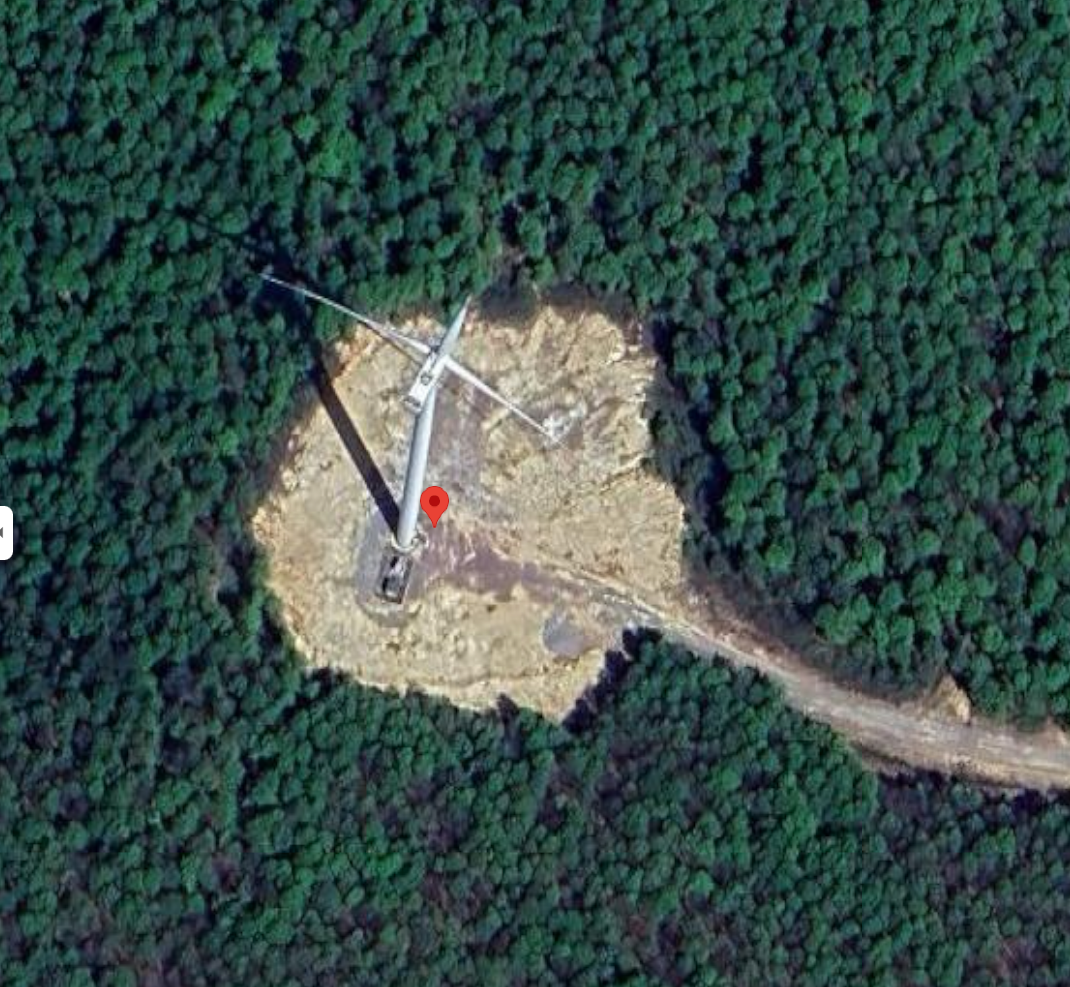

In [10]:
wind_data= pd.read_csv('data/T1.csv')
wind_data.head()

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286


Пускай "одна" установка считается по Cp Берца, а для второй возьмем действительные значения Cp

In [21]:
Nordex_berz = WindTurbine(
    name="Nordex N117 Gamma-Betz",
    Dr=116.8,
    cut_in=3.0,
    rw_speed = 10,
    cut_out=20,
    eta_m=0.94,
    cp_model="betz",
    grid_n = 25    
)

In [22]:
Nordex_real = Nordex_berz.clone(
    name="Nordex N117 Gamma-exp_data",
    cp_model="table",
    rw_speed = 14.1,
    cp_points=(V_data, Cp_data),
    eta_m=1.0
)
Nordex_real.recalc()

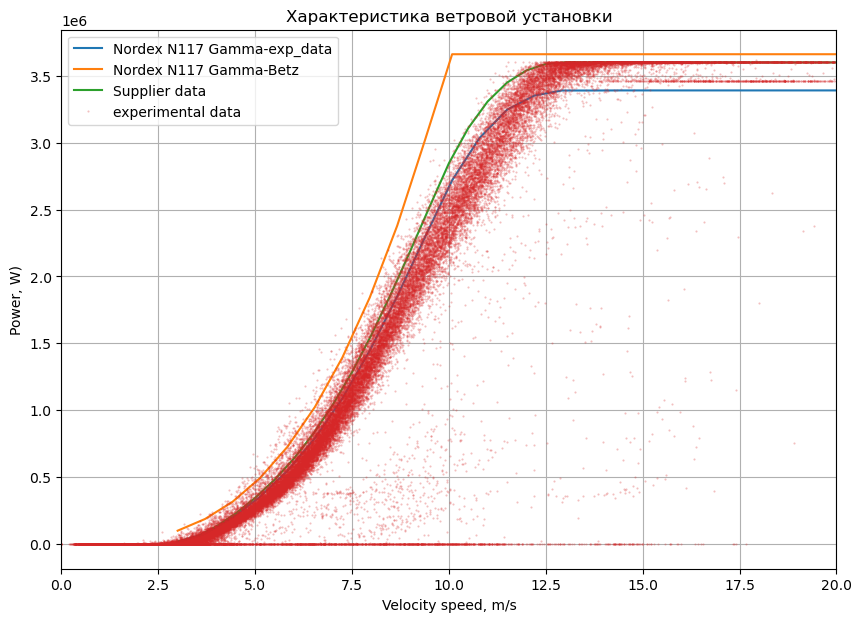

In [31]:
plt.figure(figsize=(10, 7))
plt.title('Характеристика ветровой установки')
plt.plot(Nordex_real.Vp, Nordex_real.Pturb, label=Nordex_real.name)
plt.plot(Nordex_berz.Vp, Nordex_berz.Pturb, label=Nordex_berz.name)
plt.plot(V_data, P_data*1e3, label='Supplier data')
plt.plot(wind_data['Wind Speed (m/s)'], wind_data['LV ActivePower (kW)']*1e3, 'o', alpha=0.3, markersize=0.5, label='experimental data')
plt.xlabel("Velocity speed, m/s")
plt.ylabel("Power, W)")
plt.xlim([0,20])
plt.legend()
plt.grid(True)
plt.show()